In [6]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')

# load local library
from timex import clustering
from timex import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

import datetime
from time import sleep

from aeon import datasets

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [7]:
from timex import clustering

In [65]:
MIN_TIME = 1 
MAX_TIME = 450
MIN_MEAS_COUNT = 5 # measurements
NUM_CLUSTERS = 6
INTERP_RES = 1
ANALYSIS_RES = 1
SMOOTHING_WINDOW = 7
METRIC = "euclidean"
CLUSTERING_ALGO='stdbscan'
BACKEND = 'sktime'
SMOOTHING_TYPE = 'gaussian_kernel'  # 'gaussian_kernel' or 'rolling_mean', 'gaussian_kernel_simple, 'box_kernel'
META_KEYS = ['sample', 'Time']
ID_KEY = 'sample'
TIME_KEY = 'Time'
RAW_VAL_COL = 'value'

In [68]:
TSCluster = clustering.TSDistanceBasedClustering(distance_metric = METRIC, 
                                                 method=CLUSTERING_ALGO, 
                                                 backend=BACKEND, 
                                                 n_clusters=6,
                                                 interpolation=True,
                                                 interpolation_resolution=INTERP_RES,
                                                 interpolation_keep_init=False,
                                                 smoothing_type=SMOOTHING_TYPE,
                                                 smoothing_window_size=SMOOTHING_WINDOW,
                                                 n_skip=2,
                                                 analysis_resolution=ANALYSIS_RES,
                                                 min_measurements_per_id=MIN_MEAS_COUNT, 
                                                 min_time=MIN_TIME,
                                                 max_time=MAX_TIME,
                                                 id_column=ID_KEY, 
                                                time_column=TIME_KEY,
                                                value_columns=[RAW_VAL_COL],
                                                imputation_method='knn',
                                                cross_standardisation=True,
                                                normalise_timeseries= "group",
                                                normalisation_method="standard",
                                                 )

# 1D

In [69]:
dataset = datasets.load_osuleaf()

In [70]:
dataset[0].shape

(442, 1, 427)

In [71]:
dataset[0].shape

(442, 1, 427)

In [72]:
ts_data = pd.DataFrame(dataset[0].squeeze())
ts_label = dataset[1]

ts_label_df = pd.DataFrame()
ts_label_df['label'] = ts_label
ts_label_df['sample'] = range(442)

ts_data['sample'] = ts_data.index 
ts_data_unp = ts_data.melt(id_vars='sample', value_vars=list(range(ts_data.shape[1]-1)))\
                     .sort_values(by=['sample', 'variable'])
ts_data_unp = ts_data_unp.rename(columns = {'variable': 'Time'})

In [73]:
# create heterogeinity
MAX_CUT_PERC = 0.1
MAX_MASK_PERC = 0.25
MAX_TIME_OVERALL = 426

ts_data_unp_heter = pd.DataFrame()
for s in ts_data_unp['sample'].unique():
    temp_ts = ts_data_unp.loc[(ts_data_unp['sample']==s) & (ts_data_unp['Time']<MAX_TIME_OVERALL), ['sample', 'Time', 'value']]

    max_t = temp_ts['Time'].max()
    # randomly subtract from max_t 
    new_max_t = max_t - MAX_CUT_PERC*np.random.random()*max_t
    temp_ts = temp_ts.query(f'Time<{new_max_t}')

    # random mask from remainder
    val_rem = temp_ts['value'].values
    mask = np.random.rand(val_rem.shape[0]) < MAX_MASK_PERC
    val_rem[mask] = np.nan

    temp_ts = temp_ts.assign(value=val_rem)

    ts_data_unp_heter = pd.concat([ts_data_unp_heter, temp_ts], axis=0)

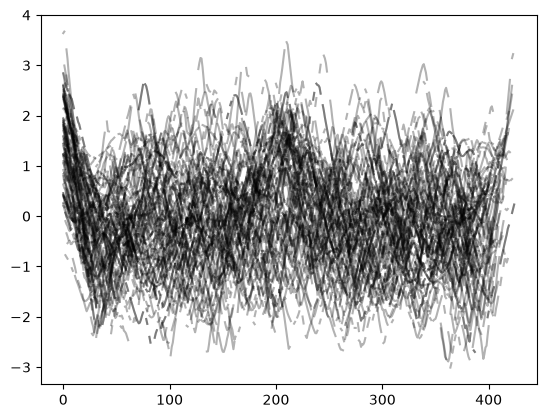

In [74]:
# plot 10 random samples
for s in ts_data_unp_heter.sample(n=100)['sample']:
    tsv = ts_data_unp_heter.query(f'sample=={s}')['value']
    tst = ts_data_unp_heter.query(f'sample=={s}')['Time']

    plt.plot(tst, tsv, color='black', alpha=0.3);

In [75]:
nunique_samples = ts_data_unp_heter['sample'].nunique()
rand_selection = np.random.choice(ts_data_unp_heter['sample'].unique(), size=nunique_samples)
TSCluster.fit(ts_data_unp_heter.loc[ts_data_unp_heter['sample'].isin(rand_selection)])

  0%|          | 0/294 [00:00<?, ?it/s]\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:119: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df = _df.replace([np.inf, -np.inf], np.nan).dropna(subset=[time_col, val_col])
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:119: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df = _df.replace([np.inf, -np.inf], np.nan).dropna(subset=[time_col, val_col])
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\

++++++++++++++++++++++++++++++++++++++++++++++++++
Final shape of fit-matrix:(294, 1, 450)
++++++++++++++++++++++++++++++++++++++++++++++++++


MemoryError: Unable to allocate 37.0 GiB for an array with shape (4968688538,) and data type float64

In [ ]:
res_cluster = pd.DataFrame(zip(TSCluster.index_, TSCluster.labels_), columns=['ID', 'cluster'])
res_cluster['cluster'] = res_cluster['cluster'].astype(int)
res_final = ts_data_unp_heter.merge(res_cluster, how='left', left_on='sample', right_on='ID').dropna(subset='ID')
res_final = res_final.merge(ts_label_df, how='left', left_on='sample', right_on='sample')

(-1.5, 2.0)

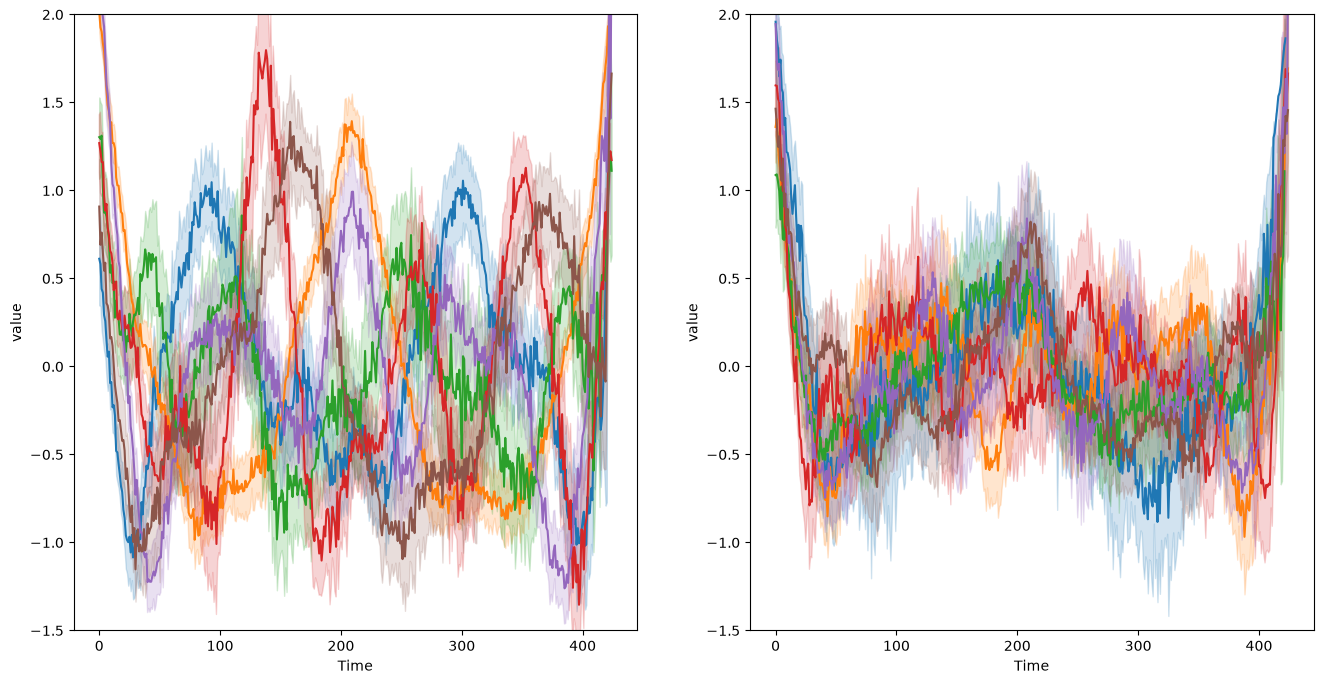

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='cluster',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[0],
             legend=False,)
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='label',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[1],
             legend=False,)

ax[0].set_ylim(-1.5,2)
ax[1].set_ylim(-1.5,2)

c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


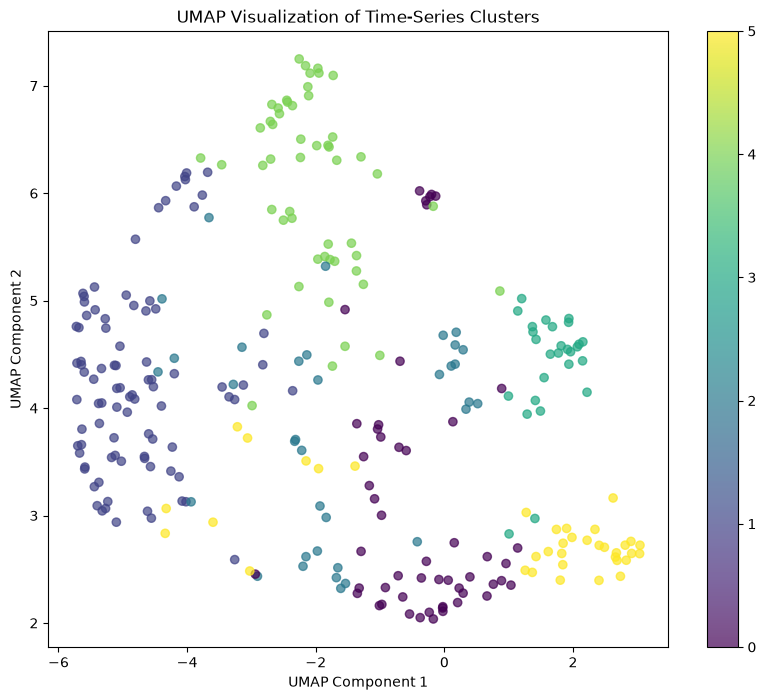

In [ ]:
TSCluster.viz();